**EXPLORATORY DATA ANALYSIS**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("D:/creditpathAI/datasets/Loan_Default.csv")

In [25]:
print("Shape of dataset")
print("Shape of dataset:", df.shape)

Shape of dataset
Shape of dataset: (255347, 18)


In [26]:
print("Data types & missing values")
print(df.info())

Data types & missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-n

In [27]:
print("Summary statistics for numerical columns")
print(df.describe())

Summary statistics for numerical columns
                 Age         Income     LoanAmount    CreditScore  \
count  255347.000000  255347.000000  255347.000000  255347.000000   
mean       43.498306   82499.304597  127578.865512     574.264346   
std        14.990258   38963.013729   70840.706142     158.903867   
min        18.000000   15000.000000    5000.000000     300.000000   
25%        31.000000   48825.500000   66156.000000     437.000000   
50%        43.000000   82466.000000  127556.000000     574.000000   
75%        56.000000  116219.000000  188985.000000     712.000000   
max        69.000000  149999.000000  249999.000000     849.000000   

       MonthsEmployed  NumCreditLines   InterestRate       LoanTerm  \
count   255347.000000   255347.000000  255347.000000  255347.000000   
mean        59.541976        2.501036      13.492773      36.025894   
std         34.643376        1.117018       6.636443      16.969330   
min          0.000000        1.000000       2.000000 

In [28]:
print("Missing value count")
print(df.isnull().sum())

Missing value count
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


***SUMMARY STATS***

In [29]:
print("DESCRIPTIVE STATS OF AGE COLUMN")
print(f'mean: {df["Age"].mean()}')
print(f'median: {df["Age"].median()}')
print(f'standard deviation: {df["Age"].std()}')
print(f'minimum: {df["Age"].min()}')
print(f'maximum: {df["Age"].max()}')
print(f'range: {df["Age"].max() - df["Age"].min()}')
print(f'variance: {df["Age"].var()}')
print(f'skewness: {df["Age"].skew()}')

DESCRIPTIVE STATS OF AGE COLUMN
mean: 43.498306226429136
median: 43.0
standard deviation: 14.990258418709589
minimum: 18
maximum: 69
range: 51
variance: 224.70784745969368
skewness: 0.0006978543690462524


***DISTRIBUTION PLOTS FOR KEY FEATURES***

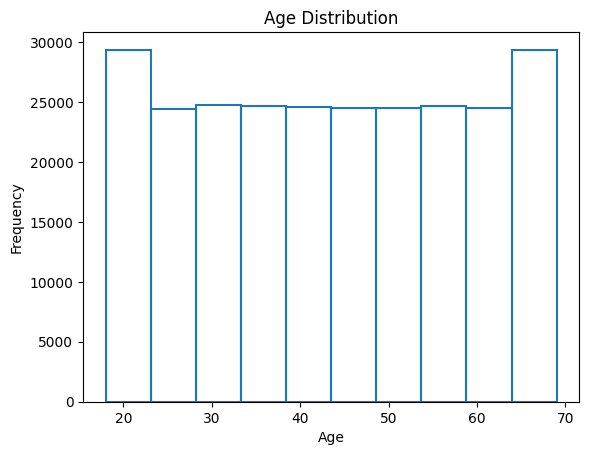

In [42]:
sns.histplot(df['Age'], bins=10,fill=False)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

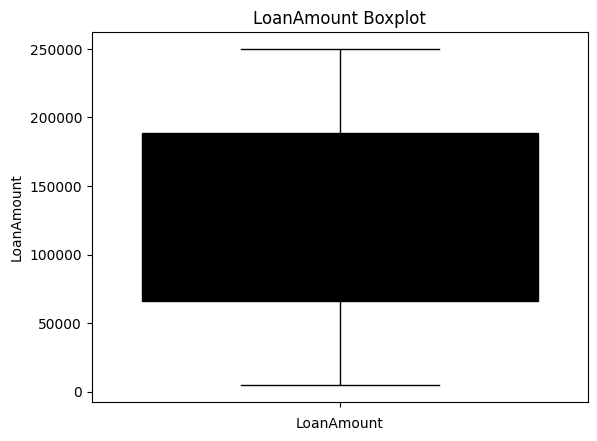

In [43]:
sns.boxplot(df['LoanAmount'],color='black')
plt.xlabel('LoanAmount')
plt.ylabel('LoanAmount')
plt.title('LoanAmount Boxplot')
plt.show()

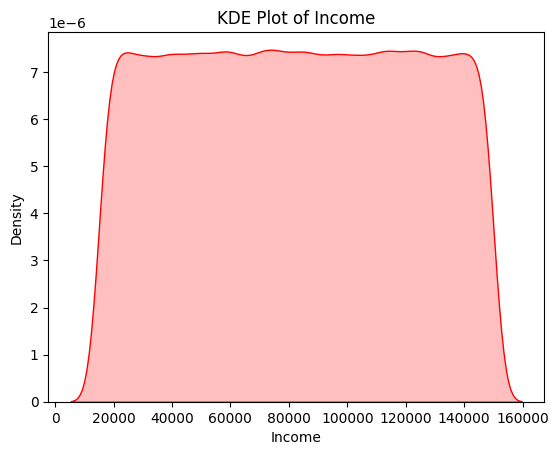

In [44]:
sns.kdeplot(df['Income'], fill=True, color="red")
plt.title("KDE Plot of Income")
plt.xlabel("Income")
plt.ylabel("Density")
plt.show()

<Axes: xlabel='EmploymentType', ylabel='Default'>

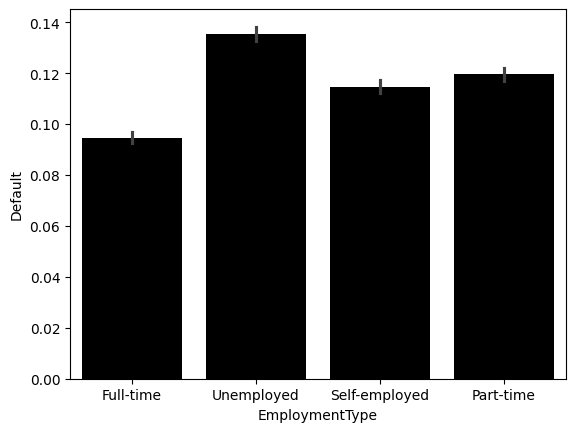

In [45]:
sns.barplot(df,x='EmploymentType',y='Default',color='black')

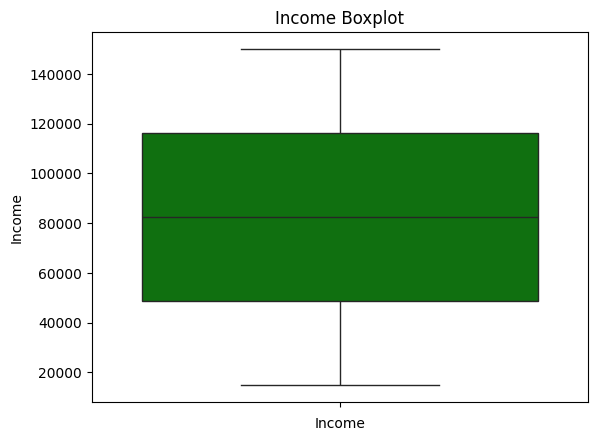

In [48]:
sns.boxplot(df['Income'],color='green')
plt.xlabel('Income')
plt.title('Income Boxplot')
plt.show()

<Axes: xlabel='HasCoSigner', ylabel='Default'>

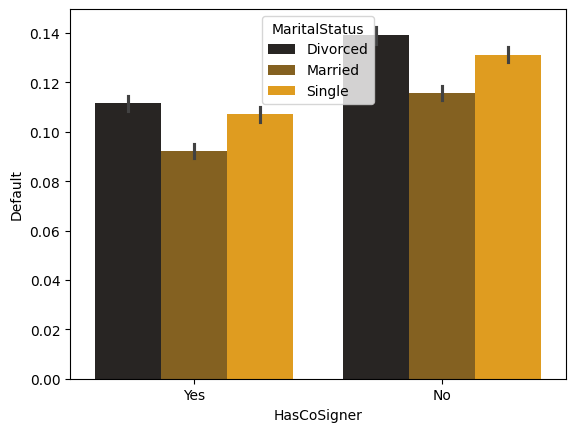

In [35]:
sns.barplot(df,x='HasCoSigner',y='Default',hue='MaritalStatus',palette='dark:orange')

***CORRELATION HEATMAP***

In [36]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'],
      dtype='object')

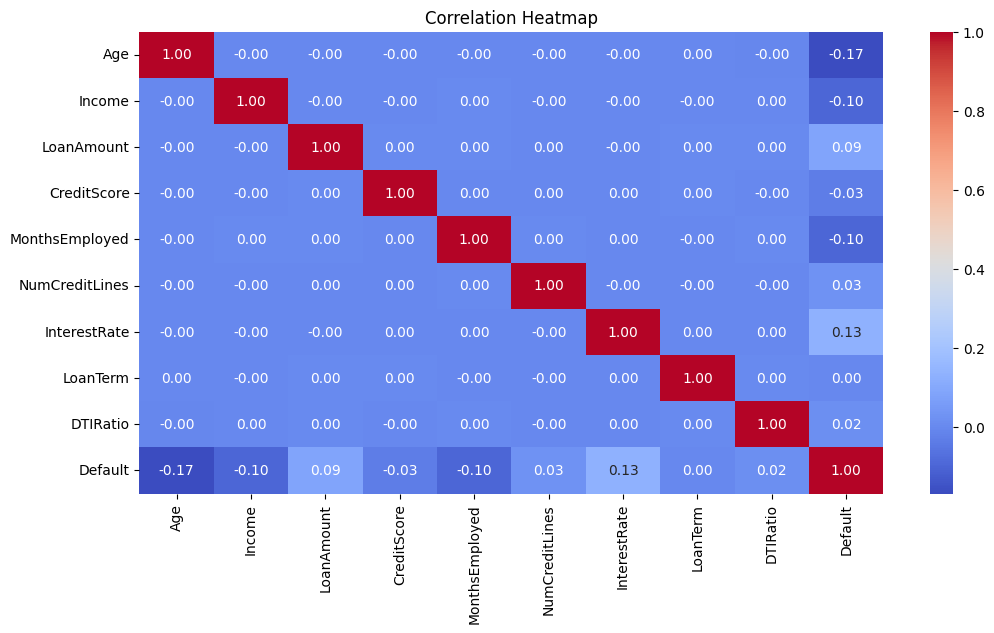

In [37]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

***OUTLIER DETECTION***

In [38]:
print("OUTLIER COUNT IN EACH NUMERIC COLUMN")
outliers = {}

for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
  outliers[col] = outlier_count

outliers

OUTLIER COUNT IN EACH NUMERIC COLUMN


{'Age': 0,
 'Income': 0,
 'LoanAmount': 0,
 'CreditScore': 0,
 'MonthsEmployed': 0,
 'NumCreditLines': 0,
 'InterestRate': 0,
 'LoanTerm': 0,
 'DTIRatio': 0,
 'Default': 29653}